In [53]:
!pip install h2o

In [54]:
AUTOML_MAX_MODELS = 100  # 100
AUTOML_SEED = 1
AUTOML_MAX_RUNTIME_SECS = 5 * 60  # 5400

In [55]:
import os
import warnings

import h2o
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from h2o.automl import H2OAutoML
from scipy.stats import spearmanr
from sklearn.preprocessing import StandardScaler

In [86]:
USE_GOOGLE_COLAB = False

if USE_GOOGLE_COLAB:
    from google.colab import drive

    drive.mount('/content/drive')
    CSV_PATH = os.path.join(os.getcwd(), 'drive', 'MyDrive', 'DSE_260A', 'data', 'cleaned_data')
    CHALLENGE_DATA_PATH = os.path.join(os.getcwd(), 'drive', 'MyDrive', 'DSE_260A', 'data', 'cleaned_data')
    SUBMISSION_PATH = os.getcwd()
    MODEL_PATH = os.getcwd()
else:
    CSV_PATH = '..'
    CHALLENGE_DATA_PATH = '../cleaned_data'
    SUBMISSION_PATH = 'submission'
    MODEL_PATH = './models'


#Final Data cleaning for Task 4.1

In [57]:
df_train = pd.read_csv(CSV_PATH + "/merged_data/combined.csv")
challenge_participants = pd.read_csv(CHALLENGE_DATA_PATH + '/challenge_participants_cleaned.csv')
challenge_hai = pd.read_csv(CHALLENGE_DATA_PATH + '/challenge_hai_cleaned.csv')
challenge_transcriptomics = pd.read_csv(CHALLENGE_DATA_PATH + '/challenge_transcriptomics_cleaned.csv')
df_challenge = challenge_hai.merge(challenge_participants, on='participant_id', how='inner')
df_challenge = df_challenge.merge(challenge_transcriptomics, on='participant_id', how='inner')

In [58]:
#drop any d28 HAI columns which are not the target column (HAI_H1N1 A/Victoria/4897/2022_d28)
df_train = df_train.drop(
    columns=[c for c in df_train.columns if (c.endswith('_d28') or c.endswith('_d365')) and c.startswith(
        'HAI') and c != 'HAI_H1N1 A/Victoria/4897/2022_d28'])

#filter out participants who do not have a baseline measurement for H1N1 A/Victoria/4897/2022 at day 0
df_train = df_train[df_train['HAI_H1N1 A/Victoria/4897/2022_d28'].isna() == False]

#filter out columns which are all NaN
df_train = df_train.dropna(axis=1, how='all')

In [59]:
df_train['DELTA'] = (df_train['HAI_H1N1 A/Victoria/4897/2022_d28'] - df_train['HAI_H1N1 A/Victoria/4897/2022_d0'])
df_train.drop(columns=['HAI_H1N1 A/Victoria/4897/2022_d28'], inplace=True)

df_train['DELTA'].value_counts()

DELTA
 0.0    152
 1.0     20
 2.0     10
-1.0      6
 3.0      6
-3.0      4
 3.0      3
-2.0      3
 4.0      3
 7.0      2
 4.0      1
 1.0      1
-4.0      1
Name: count, dtype: int64

In [60]:
#figure out which columns are common to challenge and train set

challenge_cols = set(list(df_challenge.columns))
train_cols = set(list(df_train.columns))

common_cols = challenge_cols.intersection(train_cols)
print(common_cols)

missing_from_chal = train_cols - common_cols
print(missing_from_chal)

{'HAI_H1N1 A/California/7/2009_d0', 'HAI_H1N1 A/Victoria/2570/2019_d0', 'HAI_H3N2 A/South Australia/34/2019_d0', 'HAI_Vic B/Austria/1359417/2021_d0', 'HAI_H3N2 A/Darwin/9/2021_d0', 'HAI_H3N2 A/Hong Kong/2671/2019_d0', 'HAI_Yam B/Phuket/3073/2013_d0', 'HAI_Vic B/Colorado/6/2017_d0', 'HAI_H1N1 A/Victoria/4897/2022_d0', 'PART_age', 'participant_id', 'PART_arm_name', 'HAI_H3N2 A/Kansas/14/2017_d0', 'HAI_H3N2 A/Singapore/INFIMH-160019/2016_d0', 'HAI_H1N1 A/Brisbane/2/2018_d0', 'PART_biological_sex', 'HAI_Vic B/Washington/2/2019_d0', 'HAI_H1N1 A/Guangdong-Maonan/SWL1536/2019_d0', 'HAI_H3N2 A/Tasmania/503/2020_d0'}
{'DELTA'}


In [61]:
df_train['PART_arm_name'] = df_train['PART_arm_name'].apply(lambda x: 1.0 if x == 'High Dose Fluzone' else 0.0)
df_train['PART_biological_sex'] = df_train['PART_biological_sex'].apply(lambda x: 1.0 if x == 'male' else -1.0)

scaler = StandardScaler()
df_train['PART_age'] = scaler.fit_transform(df_train[['PART_age']])
df_train.head()

,participant_id,PART_biological_sex,PART_arm_name,PART_age,HAI_H1N1 A/Brisbane/2/2018_d0,HAI_H1N1 A/California/7/2009_d0,HAI_H1N1 A/Guangdong-Maonan/SWL1536/2019_d0,HAI_H1N1 A/Victoria/2570/2019_d0,HAI_H1N1 A/Victoria/4897/2022_d0,HAI_H3N2 A/Darwin/9/2021_d0,HAI_H3N2 A/Hong Kong/2671/2019_d0,HAI_H3N2 A/Kansas/14/2017_d0,HAI_H3N2 A/Singapore/INFIMH-160019/2016_d0,HAI_H3N2 A/South Australia/34/2019_d0,HAI_H3N2 A/Tasmania/503/2020_d0,HAI_Vic B/Austria/1359417/2021_d0,HAI_Vic B/Colorado/6/2017_d0,HAI_Vic B/Washington/2/2019_d0,HAI_Yam B/Phuket/3073/2013_d0,DELTA
3466,2023_UGA.ID_002,1.0,0.0,-0.487221,6.321928,6.321928,2.321928,6.321928,2.321928,2.321928,6.321928,5.321928,4.321928,5.321928,7.321928,6.321928,6.321928,7.321928,5.321928,0.0
3467,2023_UGA.ID_014,-1.0,1.0,0.747778,3.321928,3.321928,2.321928,2.321928,2.321928,4.321928,4.321928,3.321928,4.321928,6.321928,8.321928,3.321928,2.321928,2.321928,6.321928,0.0
3468,2023_UGA.ID_039,-1.0,0.0,-1.497674,8.321928,7.321928,6.321928,3.321928,2.321928,4.321928,8.321928,6.321928,8.321928,9.321928,9.321928,2.321928,2.321928,2.321928,8.321928,0.0
3469,2023_UGA.ID_058,-1.0,0.0,0.467096,4.321928,4.321928,2.321928,2.321928,2.321928,6.321928,7.321928,5.321928,7.321928,7.321928,8.321928,5.321928,3.321928,2.321928,6.321928,0.0
3470,2023_UGA.ID_065,-1.0,0.0,-1.385401,7.321928,8.321928,4.321928,5.321928,2.321928,3.321928,9.321928,5.321928,8.321928,7.321928,8.321928,4.321928,7.321928,3.321928,9.321928,0.0


#Data preprocessing for the challenge set:

In [62]:
df_challenge = df_challenge[list(common_cols)]
df_challenge['PART_arm_name'] = df_challenge['PART_arm_name'].apply(lambda x: 1.0 if x == 'High Dose Fluzone' else 0.0)
df_challenge['PART_biological_sex'] = df_challenge['PART_biological_sex'].apply(lambda x: 1.0 if x == 'male' else -1.0)
df_challenge['PART_age'] = scaler.transform(df_challenge[['PART_age']])
df_challenge.head()

,HAI_H1N1 A/California/7/2009_d0,HAI_H1N1 A/Victoria/2570/2019_d0,HAI_H3N2 A/South Australia/34/2019_d0,HAI_Vic B/Austria/1359417/2021_d0,HAI_H3N2 A/Darwin/9/2021_d0,HAI_H3N2 A/Hong Kong/2671/2019_d0,HAI_Yam B/Phuket/3073/2013_d0,HAI_Vic B/Colorado/6/2017_d0,HAI_H1N1 A/Victoria/4897/2022_d0,PART_age,participant_id,PART_arm_name,HAI_H3N2 A/Kansas/14/2017_d0,HAI_H3N2 A/Singapore/INFIMH-160019/2016_d0,HAI_H1N1 A/Brisbane/2/2018_d0,PART_biological_sex,HAI_Vic B/Washington/2/2019_d0,HAI_H1N1 A/Guangdong-Maonan/SWL1536/2019_d0,HAI_H3N2 A/Tasmania/503/2020_d0
0,4.321928,2.321928,6.321928,4.321928,2.321928,4.321928,4.321928,2.321928,2.321928,0.972323,2024_UGA.ID_077,1.0,3.321928,3.321928,2.321928,-1.0,2.321928,2.321928,3.321928
1,9.321928,6.321928,4.321928,5.321928,2.321928,2.321928,5.321928,5.321928,4.321928,0.579369,2024_UGA.ID_086,1.0,2.321928,2.321928,8.321928,1.0,4.321928,9.321928,3.321928
2,7.321928,6.321928,8.321928,3.321928,6.321928,7.321928,5.321928,3.321928,5.321928,-0.655629,2024_UGA.ID_128,0.0,7.321928,7.321928,6.321928,-1.0,3.321928,6.321928,7.321928
3,3.321928,5.321928,5.321928,3.321928,3.321928,5.321928,3.321928,2.321928,2.321928,1.084595,2024_UGA.ID_170,1.0,4.321928,4.321928,3.321928,-1.0,2.321928,3.321928,6.321928
4,3.321928,6.321928,4.321928,5.321928,4.321928,3.321928,7.321928,4.321928,2.321928,0.860050,2024_UGA.ID_179,1.0,6.321928,2.321928,5.321928,-1.0,4.321928,2.321928,3.321928


In [63]:
df_train = df_train[list(common_cols) + ['DELTA']]
df_train.to_csv(os.path.join(os.getcwd(), '4.1_train_temp.csv'), index=False)

# Task 4.1

**4.1 predict magnitude of antibody response - H1N1 A/Victoria/4897/2022 (D28)**
* Training Data: Demographics + Day 0 + Day 7 innate
* Assay: HAI
* Measure: Single strain titer
* Metric: Spearman correlation
* Full description: HAI titer for H1N1 A/Victoria/4897/2022 at Day 28

In [64]:
TARGET_COL = 'DELTA'  # task 4.1

In [65]:
warnings.filterwarnings("ignore", category=UserWarning, module="h2o")
h2o.init()

Checking whether there is an H2O instance running at http://localhost:54321. connected.


H2O_cluster_uptime:,27 mins 43 secs
H2O_cluster_timezone:,America/Los_Angeles
H2O_data_parsing_timezone:,UTC
H2O_cluster_version:,3.46.0.11
H2O_cluster_version_age:,9 days
H2O_cluster_name:,H2O_from_python_Brian_gzztjn
H2O_cluster_total_nodes:,1
H2O_cluster_free_memory:,1.615 Gb
H2O_cluster_total_cores:,4
H2O_cluster_allowed_cores:,4
H2O_cluster_status:,"locked, healthy"


In [66]:
data = h2o.import_file(os.path.join(os.getcwd(), '4.1_train_temp.csv'))
os.remove(os.path.join(os.getcwd(), '4.1_train_temp.csv'))

Parse progress: |████████████████████████████████████████████████████████████████| (done) 100%


In [67]:
x = [c for c in data.columns if c != 'participant_id']
y = TARGET_COL
x = [c for c in x if c != y]

In [68]:
train, test = data.split_frame(ratios=[.8], seed=1234)

In [69]:
aml = H2OAutoML(
    max_models=AUTOML_MAX_MODELS,
    seed=AUTOML_SEED,
    nfolds=5,
    keep_cross_validation_predictions=True,
    max_runtime_secs=AUTOML_MAX_RUNTIME_SECS
)

aml.train(x=x, y=y, training_frame=train)

AutoML progress: |
16:36:57.277: _min_rows param, The dataset size is too small to split for min_rows=100.0: must have at least 200.0 (weighted) rows, but have only 169.0.

███████████████████████████████████████████████████████████████| (done) 100%


Model Details
=============
H2OGeneralizedLinearEstimator : Generalized Linear Modeling
Model Key: GLM_1_AutoML_3_20260531_163655


GLM Model: summary
    family    link      regularization             lambda_search                                                                number_of_predictors_total    number_of_active_predictors    number_of_iterations    training_frame
--  --------  --------  -------------------------  ---------------------------------------------------------------------------  ----------------------------  -----------------------------  ----------------------  ------------------------------------------------
    gaussian  identity  Ridge ( lambda = 11.636 )  nlambda = 30, lambda.max = 11.636, lambda.min = 11.636, lambda.1se = 11.636  18                            18                             1                       AutoML_3_20260531_163655_training_py_20_sid_884c

ModelMetricsRegressionGLM: glm
** Reported on train data. **

MSE: 1.6769866703721914
RMSE: 1.294985200831342
MAE: 0.7989462329732552
RMSLE: NaN
Mean Residual Deviance: 1.6769866703721914
R^2: 0.004522253554055555
Null degrees of freedom: 168
Residual degrees of freedom: 150
Null deviance: 284.698224852071
Residual deviance: 283.41074729290034
AIC: 606.9739765221562

ModelMetricsRegressionGLM: glm
** Reported on cross-validation data. **

MSE: 1.710162749153669
RMSE: 1.3077319102758291
MAE: 0.803802220809637
RMSLE: NaN
Mean Residual Deviance: 1.710162749153669
R^2: -0.015171431986073847
Null degrees of freedom: 168
Residual degrees of freedom: 150
Null deviance: 286.53801726603257
Residual deviance: 289.0175046069701
AIC: 610.2846876402458

Cross-Validation Metrics Summary: 
                        mean       sd         cv_1_valid    cv_2_valid    cv_3_valid    cv_4_valid    cv_5_valid
----------------------  ---------  ---------  ------------  ------------  ------------  ------------  ------------
aic                     149.542    20.2382    142.342       134.077       171.864       170.317       129.11
loglikelihood           0          0          0             0             0             0             0
mae                     0.803009   0.147688   0.72336       0.699638      0.992967      0.930133      0.668946
mean_residual_deviance  1.70523    0.978086   1.1879        0.931558      2.83059       2.70463       0.871467
mse                     1.70523    0.978086   1.1879        0.931558      2.83059       2.70463       0.871467
null_deviance           57.3076    33.3028    39.7649       31.2565       95.2565       91.7042       28.5558
r2                      -0.027539  0.0160655  -0.0156872    -0.0197736    -0.0124263    -0.0446233    -0.0451845
residual_deviance       57.8035    33.4424    40.3885       31.673        96.24         91.9576       28.7584
rmse                    1.26312    0.370386   1.08991       0.965172      1.68244       1.64458       0.933524
rmsle                   nan        0          nan           nan           nan           nan           nan

Scoring History: 
    timestamp            duration    iteration    lambda    predictors    deviance_train    deviance_xval    deviance_se    alpha    iterations    training_rmse    training_deviance    training_mae    training_r2
--  -------------------  ----------  -----------  --------  ------------  ----------------  ---------------  -------------  -------  ------------  ---------------  -------------------  --------------  -------------
    2026-05-31 16:36:57  0.000 sec   1            12        19            1.67699           1.70523          0.437413       0
    2026-05-31 16:36:57  0.001 sec   2            8.5       19            1.67439           0                0              0        2             1.29499          1.67699              0.798946        0.00452225

Variable Importances: 
variable                                     relative_importance    scaled_importance    percentage
-------------------------------------------  ---------------------  ---------

In [70]:
lb = aml.leaderboard
print(lb.head(rows=lb.nrows))

model_id                                                 rmse      mse       mae    rmsle    mean_residual_deviance
GLM_1_AutoML_3_20260531_163655                        1.30773  1.71016  0.803802      nan                   1.71016
GBM_grid_1_AutoML_3_20260531_163655_model_4           1.32386  1.75261  0.810676      nan                   1.75261
XGBoost_grid_1_AutoML_3_20260531_163655_model_28      1.32809  1.76383  0.794954      nan                   1.76383
XGBoost_grid_1_AutoML_3_20260531_163655_model_15      1.32868  1.76539  0.800198      nan                   1.76539
GBM_grid_1_AutoML_3_20260531_163655_model_1           1.33098  1.7715   0.84276       nan                   1.7715
XGBoost_grid_1_AutoML_3_20260531_163655_model_21      1.33215  1.77463  0.816132      nan                   1.77463
GBM_grid_1_AutoML_3_20260531_163655_model_11          1.33249  1.77553  0.807888      nan                   1.77553
GBM_grid_1_AutoML_3_20260531_163655_model_20          1.33818  1.79073  0

In [71]:
print(aml.leader)

Model Details
H2OGeneralizedLinearEstimator : Generalized Linear Modeling
Model Key: GLM_1_AutoML_3_20260531_163655


GLM Model: summary
    family    link      regularization             lambda_search                                                                number_of_predictors_total    number_of_active_predictors    number_of_iterations    training_frame
--  --------  --------  -------------------------  ---------------------------------------------------------------------------  ----------------------------  -----------------------------  ----------------------  ------------------------------------------------
    gaussian  identity  Ridge ( lambda = 11.636 )  nlambda = 30, lambda.max = 11.636, lambda.min = 11.636, lambda.1se = 11.636  18                            18                             1                       AutoML_3_20260531_163655_training_py_20_sid_884c

ModelMetricsRegressionGLM: glm
** Reported on train data. **

MSE: 1.6769866703721914
RMSE: 1.294985200831342


In [72]:
predictions = aml.leader.predict(test)

results = test[y].cbind(predictions["predict"])
results.columns = ["actual", "predicted"]

# Filter out rows where actual is NaN
results_clean = results[results["actual"].isna() == 0]

print(results_clean.head(20))

glm prediction progress: |███████████████████████████████████████████████████████| (done) 100%
  actual    predicted
       0     0.353126
       0     0.353628
       0     0.344585
       0     0.361296
       0     0.347014
       0     0.345105
       0     0.373794
       0     0.373248
      -3     0.328753
       0     0.352222
       0     0.353787
      -1     0.365772
       0     0.345962
       0     0.357483
       0     0.349098
       0     0.360546
       0     0.349253
       1     0.358337
       1     0.367153
       0     0.352665
[20 rows x 2 columns]



Spearman (results_clean): 0.120  (p-value: 0.4441)


/Users/Brian/miniconda3/envs/python311/lib/python3.11/site-packages/h2o/frame.py:1983: H2ODependencyWarning: Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using multi-thread, install polars and pyarrow and use it as pandas_df = h2o_df.as_data_frame(use_multi_thread=True)

  warnings.warn("Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using"
/Users/Brian/miniconda3/envs/python311/lib/python3.11/site-packages/h2o/frame.py:1983: H2ODependencyWarning: Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using multi-thread, install polars and pyarrow and use it as pandas_df = h2o_df.as_data_frame(use_multi_thread=True)

  warnings.warn("Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using"


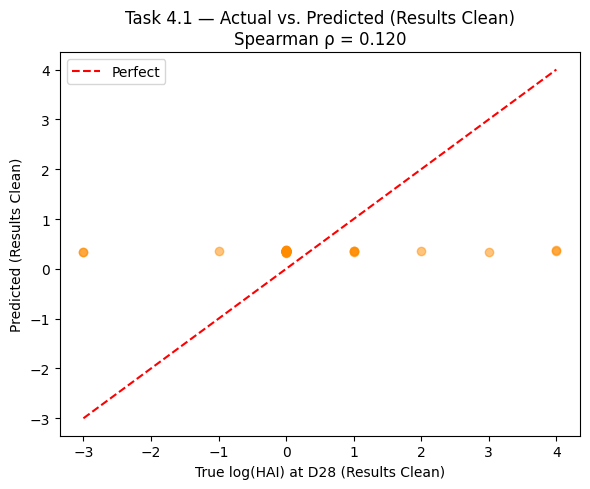

In [73]:
actual_values = results_clean['actual'].as_data_frame(use_multi_thread=True).to_numpy()
predicted_values = results_clean['predicted'].as_data_frame(use_multi_thread=True).to_numpy()

rho_results, pval_results = spearmanr(actual_values, predicted_values)
print(f'Spearman (results_clean): {rho_results:.3f}  (p-value: {pval_results:.4f})')

plt.figure(figsize=(6, 5))
plt.scatter(actual_values, predicted_values, alpha=0.5, color='darkorange')
plt.plot([actual_values.min(), actual_values.max()], [actual_values.min(), actual_values.max()], 'r--', label='Perfect')
plt.xlabel('True log(HAI) at D28 (Results Clean)')
plt.ylabel('Predicted (Results Clean)')
plt.title(f'Task 4.1 — Actual vs. Predicted (Results Clean)\nSpearman ρ = {rho_results:.3f}')
plt.legend()
plt.tight_layout()
plt.show()

/Users/Brian/miniconda3/envs/python311/lib/python3.11/site-packages/h2o/frame.py:1983: H2ODependencyWarning: Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using multi-thread, install polars and pyarrow and use it as pandas_df = h2o_df.as_data_frame(use_multi_thread=True)

  warnings.warn("Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using"


First 5 actual HAI D28 values (Original Scale):
 [[5.]
 [5.]
 [5.]
 [5.]
 [5.]]

First 5 predicted HAI D28 values (Original Scale):
 [[6.38662718]
 [6.38884748]
 [6.3489302 ]
 [6.42289684]
 [6.35962667]]


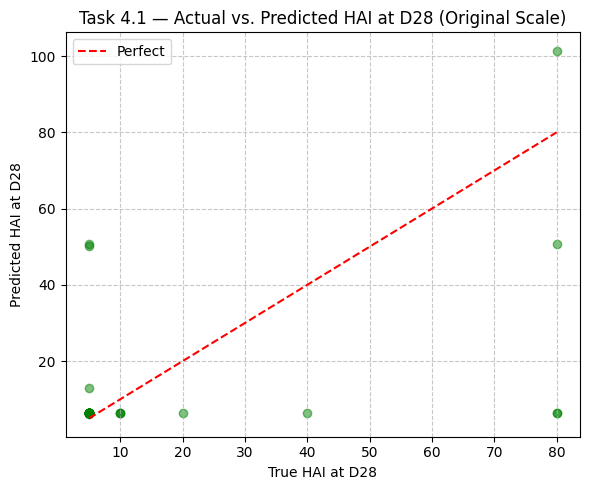

In [74]:
# Flag to toggle between log scale (1) and original scale (0) results
convert_to_original_scale = 0  # Set to 0 for original scale, 1 for log2 scale

# Get the Day 0 HAI values for the test set corresponding to the cleaned results
test_d0_hai_column_name = TARGET_COL.replace('DELTA', 'HAI_H1N1 A/Victoria/4897/2022_d0')

# Filter the original 'test' H2OFrame using the same condition that created results_clean.
# results_clean was created from `results[results["actual"].isna() == 0]`,
# where `results["actual"]` corresponds to `test[y]` for the relevant rows.
filtered_test_for_d0_h2o = test[test[y].isna() == 0]

# Now, extract the d0 HAI column from this filtered H2OFrame
test_d0_hai_h2o_filtered = filtered_test_for_d0_h2o[test_d0_hai_column_name]

# Convert it to a numpy array. The 'actual_values' and 'predicted_values' are already numpy arrays.
test_d0_hai = test_d0_hai_h2o_filtered.as_data_frame(use_multi_thread=True).values.reshape(-1, 1)

# Calculate actual HAI d28 values (log2 scale)
actual_hai_d28_log2 = test_d0_hai + actual_values

# Calculate predicted HAI d28 values (log2 scale)
predicted_hai_d28_log2 = test_d0_hai + predicted_values

if convert_to_original_scale == 0:
    # Convert to original HAI titer scale (exp2)
    display_actual_values = np.exp2(actual_hai_d28_log2)
    display_predicted_values = np.exp2(predicted_hai_d28_log2)
    scale_label = 'Original Scale'
    x_label = 'True HAI at D28'
    y_label = 'Predicted HAI at D28'
else:
    display_actual_values = actual_hai_d28_log2
    display_predicted_values = predicted_hai_d28_log2
    scale_label = 'Log2 Scale'
    x_label = 'True log2(HAI) at D28'
    y_label = 'Predicted log2(HAI) at D28'

print(f"First 5 actual HAI D28 values ({scale_label}):\n", display_actual_values[:5])
print(f"\nFirst 5 predicted HAI D28 values ({scale_label}):\n", display_predicted_values[:5])

# Plotting the HAI values
plt.figure(figsize=(6, 5))
plt.scatter(display_actual_values, display_predicted_values, alpha=0.5, color='green')
plt.plot([display_actual_values.min(), display_actual_values.max()],
         [display_actual_values.min(), display_actual_values.max()], 'r--', label='Perfect')
plt.xlabel(x_label)
plt.ylabel(y_label)
plt.title(f'Task 4.1 — Actual vs. Predicted HAI at D28 ({scale_label})')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [75]:
#calculate the spearman
rho_results, pval_results = spearmanr(display_actual_values, display_predicted_values)

print(f'Spearman: {rho_results}')

Spearman: 0.18640481323573196


#Use AutoML model to predict challenge set

In [76]:
lb_df = aml.leaderboard.as_data_frame(use_multi_thread=True)
top_model = h2o.get_model(lb_df['model_id'].iloc[0])

challenge_hf = h2o.H2OFrame(df_challenge)
try:
    y_pred_challenge = top_model.predict(challenge_hf).as_data_frame(use_multi_thread=True)['predict']
except OSError:
    fallback_id = lb_df[~lb_df['model_id'].str.contains('StackedEnsemble')]['model_id'].iloc[0]
    top_model = h2o.get_model(fallback_id)
    y_pred_challenge = top_model.predict(challenge_hf).as_data_frame(use_multi_thread=True)['predict']

results = pd.DataFrame({
    'participant_id': df_challenge['participant_id'].values,
    'Task_4.1': y_pred_challenge,
})

results = results.merge(df_challenge[['participant_id', 'HAI_H1N1 A/Victoria/4897/2022_d0']], on='participant_id',
                        how='inner')
results['Task_4.1'] = np.exp2(results['Task_4.1'] + results['HAI_H1N1 A/Victoria/4897/2022_d0'])
d0 = results.copy(deep=True)
results.drop(columns=['HAI_H1N1 A/Victoria/4897/2022_d0'], inplace=True)
results

Parse progress: |

/Users/Brian/miniconda3/envs/python311/lib/python3.11/site-packages/h2o/frame.py:1983: H2ODependencyWarning: Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using multi-thread, install polars and pyarrow and use it as pandas_df = h2o_df.as_data_frame(use_multi_thread=True)

  warnings.warn("Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using"


████████████████████████████████████████████████████████████████| (done) 100%
glm prediction progress: |███████████████████████████████████████████████████████| (done) 100%


/Users/Brian/miniconda3/envs/python311/lib/python3.11/site-packages/h2o/frame.py:1983: H2ODependencyWarning: Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using multi-thread, install polars and pyarrow and use it as pandas_df = h2o_df.as_data_frame(use_multi_thread=True)

  warnings.warn("Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using"


,participant_id,Task_4.1
0,2024_UGA.ID_077,6.409173
1,2024_UGA.ID_086,25.924374
2,2024_UGA.ID_128,50.694397
3,2024_UGA.ID_170,6.365870
4,2024_UGA.ID_179,6.394063
5,2024_UGA.ID_215,6.375315
6,2024_UGA.ID_219,6.466723
7,2024_UGA.ID_275,12.800970
8,2024_UGA.ID_295,25.678706
9,2024_UGA.ID_296,6.473818


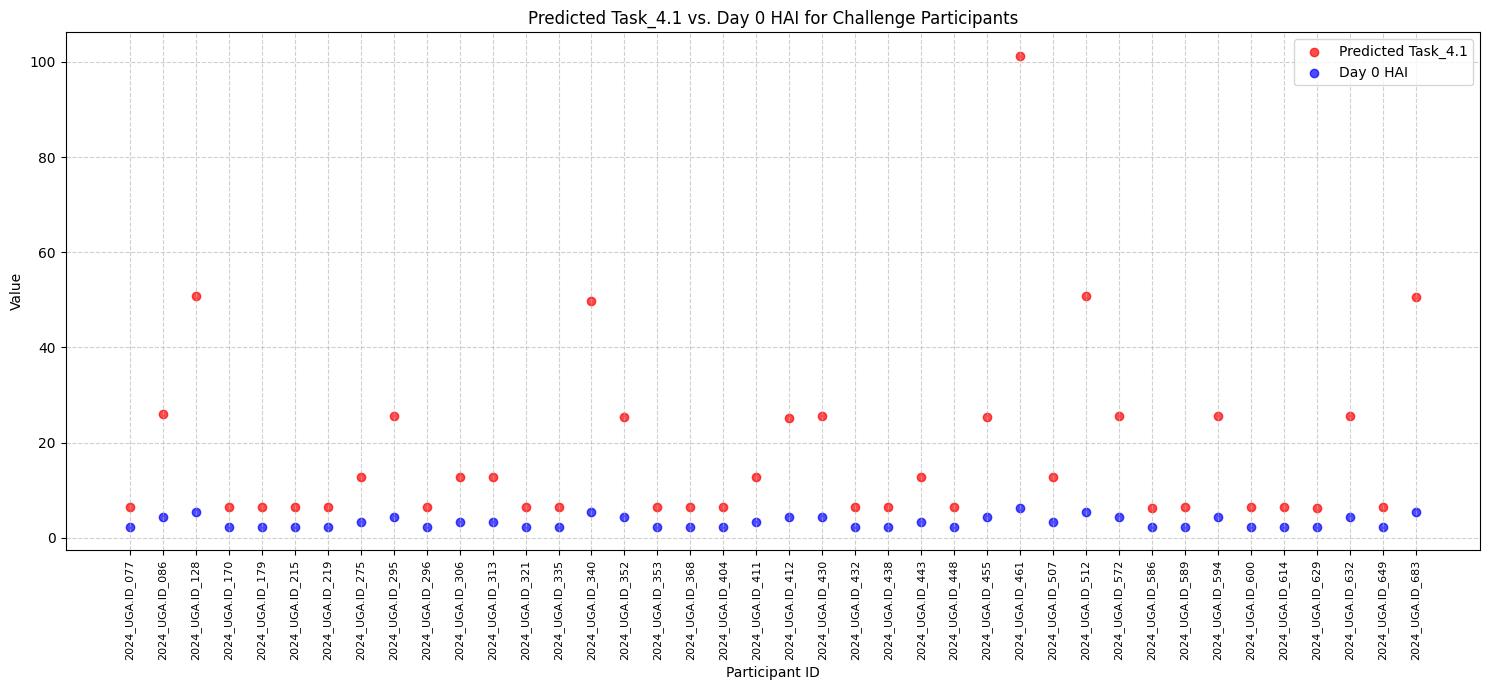

In [77]:
plt.figure(figsize=(15, 7))

# Plot predicted Task_4.1 values
plt.scatter(d0['participant_id'], d0['Task_4.1'], color='red', label='Predicted Task_4.1', alpha=0.7)

# Plot Day 0 HAI values (d0 value)
plt.scatter(d0['participant_id'], d0['HAI_H1N1 A/Victoria/4897/2022_d0'], color='blue', label='Day 0 HAI', alpha=0.7)

plt.xlabel('Participant ID')
plt.ylabel('Value')
plt.title('Predicted Task_4.1 vs. Day 0 HAI for Challenge Participants')
plt.xticks(rotation=90, fontsize=8)  # Rotate x-axis labels for readability
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

In [87]:
#output to csv
results.to_csv(SUBMISSION_PATH + '/task_4_1.csv', index=False)

In [90]:
model_path = h2o.save_model(
    model=aml.leader,
    path=MODEL_PATH,
    force=True
)

print(model_path)

os.rename(model_path, os.path.join(MODEL_PATH, 'model_4.1'))

/Users/Brian/Desktop/2024-b6hill/DSE260/cmi-flu-prediction-challenge-capstone/automl_models/models/GLM_1_AutoML_3_20260531_163655
